In [1]:
import matplotlib.pyplot as pl
import numpy as np
import pandas as pd
import xarray as xr
import math
import pickle
import os


from fair import FAIR
from fair.interface import fill, initialise
from fair.io import read_properties
from pygments.lexers.textfmts import TodotxtLexer

import statsmodels.api as sm
import pmdarima as pm


In [2]:
with open("/glade/work/stevenxu/FAIR_models/origional_model_extension.pkl", "rb") as f_in:
    f1 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top12_model_extension.pkl", "rb") as f_in:
    #f2 = pickle.load(f_in)

#with open("/glade/work/stevenxu/FAIR_models/top20_model_extension.pkl", "rb") as f_in:
    #f3 = pickle.load(f_in)

# Forcing

In [92]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_forcing_extension.pkl", "rb") as f:
    arima_list = pickle.load(f)

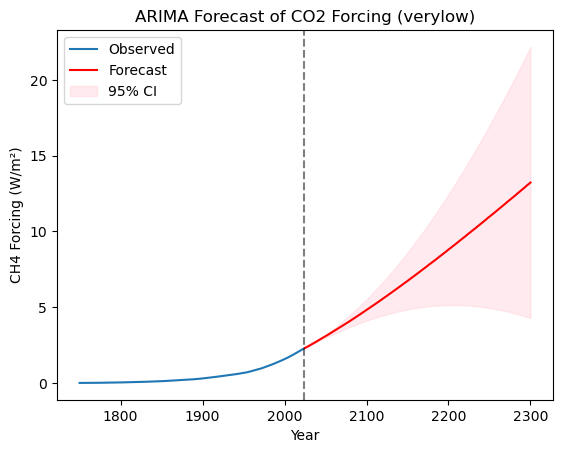

In [94]:
startyear = 2024
endyear = 2300
specie = 'CO2'
model = arima_list[specie]

da = f1.forcing.sel(specie=specie, scenario = f1.scenarios[5], timebounds = slice(None, startyear)).mean(dim="config")
ffl_fc, ffl_conf_int = model.predict(n_periods=endyear-startyear, return_conf_int=True)


# historical data
pl.plot(da["timebounds"].values, da.values, label="Observed")

# forecast horizon (years after yrfcm = 2024)
future_years = np.arange(startyear + 1, endyear + 1)

# forecast mean
pl.plot(future_years, ffl_fc, label="Forecast", color="red")

# confidence interval
pl.fill_between(
    future_years,
    ffl_conf_int[:, 0],
    ffl_conf_int[:, 1],
    color="pink",
    alpha=0.3,
    label="95% CI"
)

pl.axvline(startyear, color="k", linestyle="--", alpha=0.5)
pl.xlabel("Year")
pl.ylabel("CH4 Forcing (W/m²)")
pl.title(f"ARIMA Forecast of {specie} Forcing ({da.scenario.values})")
pl.legend()
pl.show()


In [97]:
save_dir = "/glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/forcing/extension"

for specie, model in arima_list.items():
	print(f"start plotting {specie}")
	startyear = 2024
	endyear   = 2300
	scenario_for_forecast = f1.scenarios[5]

	fig, ax = pl.subplots(figsize=(8,5))

	# historical
	da_hist = (
		f1.forcing
		.sel(specie=specie, scenario=scenario_for_forecast, timebounds=slice(None, startyear))
		.mean(dim="config")
	)
	ax.plot(da_hist["timebounds"].values, da_hist.values,
			linewidth=2.5, color="k", label=f"historical")

	#prediction
	model = arima_list[specie]
	n_steps = endyear - startyear
	ffl_fc, ffl_conf_int = model.predict(n_periods=n_steps, return_conf_int=True)
	future_years = np.arange(startyear + 1, endyear + 1)
	ax.plot(future_years, ffl_fc, linewidth=2, color="black", linestyle="--", label="ARIMA forecast")

	# CI interval
	ax.fill_between(future_years, ffl_conf_int[:,0], ffl_conf_int[:,1],
					alpha=0.2, label="95% CI")

	# plot scenarios
	for scen in f1.scenarios:
		da_all = (
			f1.forcing
			.sel(specie=specie, scenario=scen, timebounds=slice(startyear, endyear))
			.mean(dim="config")
		)
		ax.plot(da_all["timebounds"].values, da_all.values, label=str(scen))

	# views
	ax.axvline(startyear, color="k", linestyle=":", alpha=0.6)
	ax.set_xlabel("Year")
	ax.set_ylabel("Forcing (W/m^2)")
	ax.set_title(f"ARIMA Forecast of {specie} Forcing")
	ax.legend(loc="best", ncol=1, frameon=True)
	#pl.show()

	save_path = os.path.join(save_dir, f"{specie}_arima_forecast.png")
	pl.savefig(save_path, dpi=300, bbox_inches="tight")
	pl.close()
  


start plotting CO2
start plotting CH4
start plotting N2O
start plotting CFC-11
start plotting CFC-12
start plotting CFC-113
start plotting CFC-114
start plotting CFC-115
start plotting HCFC-22
start plotting HCFC-141b
start plotting HCFC-142b
start plotting CCl4
start plotting CHCl3
start plotting CH2Cl2
start plotting CH3Cl
start plotting CH3CCl3
start plotting CH3Br
start plotting Halon-1211
start plotting Halon-1301
start plotting Halon-2402
start plotting CF4
start plotting C2F6
start plotting C3F8
start plotting c-C4F8
start plotting C4F10
start plotting C5F12
start plotting C6F14
start plotting C7F16
start plotting C8F18
start plotting NF3
start plotting SF6
start plotting SO2F2
start plotting HFC-125
start plotting HFC-134a
start plotting HFC-143a
start plotting HFC-152a
start plotting HFC-227ea
start plotting HFC-23
start plotting HFC-236fa
start plotting HFC-245fa
start plotting HFC-32
start plotting HFC-365mfc
start plotting HFC-4310mee
start plotting Solar
start plotting Vol

# Emission

In [3]:
with open("/glade/work/stevenxu/FAIR_models/arima_list_emission_extension.pkl", "rb") as f:
    arima_list = pickle.load(f)

In [4]:
arima_list.pop('c-C4F8')

ARIMA(order=(0, 1, 0), scoring_args={}, seasonal_order=(2, 1, 0, 12),
      suppress_warnings=True, with_intercept=False)

In [74]:
save_dir = "/glade/u/home/stevenxu/FAIRproject/graph_outputs/arima_plots/emission/extension"

for specie, model in arima_list.items():
	print(f"start plotting {specie}")
	startyear = 2023
	endyear   = 2300
	scenario_for_forecast = f1.scenarios[5]

	fig, ax = pl.subplots(figsize=(8,5))

	# historical
	da_hist = (
		f1.emissions
		.sel(specie=specie, scenario=scenario_for_forecast, timepoints=slice(None, startyear))
		.mean(dim="config")
	)
	ax.plot(da_hist["timepoints"].values, da_hist.values,
			linewidth=2.5, color="k", label=f"historical")

	#prediction
	model = arima_list[specie]
	n_steps = endyear - startyear
	ffl_fc, ffl_conf_int = model.predict(n_periods=n_steps, return_conf_int=True)
	future_years = np.arange(startyear + 1, endyear + 1)
	ax.plot(future_years, ffl_fc, linewidth=2, color="black", linestyle="--", label="ARIMA forecast")

	# CI interval
	ax.fill_between(future_years, ffl_conf_int[:,0], ffl_conf_int[:,1],
					alpha=0.2, label="95% CI")

	# plot scenarios
	for scen in f1.scenarios:
		da_all = (
			f1.emissions
			.sel(specie=specie, scenario=scen, timepoints=slice(startyear, endyear))
			.mean(dim="config")
		)
		ax.plot(da_all["timepoints"].values, da_all.values, label=str(scen))

	# views
	ax.axvline(startyear, color="k", linestyle=":", alpha=0.6)
	ax.set_xlabel("Year")
	ax.set_ylabel("Emission (Mt/yr)")
	ax.set_title(f"ARIMA Forecast of {specie} Emission")
	ax.legend(loc="best", ncol=1, frameon=True)
	#pl.show()

	save_path = os.path.join(save_dir, f"{specie}_arima_forecast.png")
	pl.savefig(save_path, dpi=300, bbox_inches="tight")
	pl.close()
  


start plotting CO2 FFI
start plotting CO2 AFOLU
start plotting CO2
start plotting CH4
start plotting N2O
start plotting Sulfur
start plotting BC
start plotting OC
start plotting NH3
start plotting NOx
start plotting VOC
start plotting CO
start plotting CFC-11
start plotting CFC-12
start plotting CFC-113
start plotting CFC-114
start plotting CFC-115
start plotting HCFC-22
start plotting HCFC-141b
start plotting HCFC-142b
start plotting CCl4
start plotting CHCl3
start plotting CH2Cl2
start plotting CH3Cl
start plotting CH3CCl3
start plotting CH3Br
start plotting Halon-1211
start plotting Halon-1301
start plotting Halon-2402
start plotting CF4
start plotting C2F6
start plotting C3F8
start plotting C4F10
start plotting C5F12
start plotting C6F14
start plotting C7F16
start plotting C8F18
start plotting NF3
start plotting SF6
start plotting SO2F2
start plotting HFC-125
start plotting HFC-134a
start plotting HFC-143a
start plotting HFC-152a
start plotting HFC-227ea
start plotting HFC-23
start